In [14]:
from astropy import units as u
from astropy import time
import astropy
import numpy as np

from poliastro import iod
from poliastro.bodies import Body,Mars, Earth, Venus, Jupiter, Saturn, Uranus, Neptune, Sun, Europa, Ganymede, Callisto, Io, Titan
from poliastro.ephem import Ephem
from poliastro.maneuver import Maneuver
from poliastro.twobody import Orbit
from poliastro.util import time_range
from poliastro.frames import Planes
from poliastro.frames.fixed import JupiterFixed
from poliastro.frames.equatorial import JupiterICRS
from astroquery.jplhorizons import Horizons
from copy import deepcopy

from scipy import ndimage
from scipy.spatial.transform import Rotation as scipyRot
from collections import defaultdict
from poliastro.plotting import OrbitPlotter3D, StaticOrbitPlotter
import math
import matplotlib.pyplot as plt
# More info: https://plotly.com/python/renderers/
import plotly.io as pio
from poliastro.util import norm, time_range
pio.renderers.default = "plotly_mimetype+notebook_connected"
import weakref
from astropy.coordinates import solar_system_ephemeris
from collections.abc import Mapping
from poliastro.extra_util import get_galilean_orbs, ecliptic_slingshot, get_galilean_ephemerides, slingshot_to_another_body
# from poliastro.extra_util import *
solar_system_ephemeris.set("jpl")

<ScienceState solar_system_ephemeris: 'jpl'>

In [15]:
##Incriments spacecraft by tof_step forward and scans over all allowed tofs

def get_single_burn_elliptical_hohmann_brute_force(target_orb, initial_orb,min_departure_wait=0*u.day,max_depature_wait=50*u.day, min_tof=0.1*u.day, max_tof=50*u.day, tof_step=0.1*u.day, retrograde_only=False,fine_scan=False,max_encounter_v=20*u.km/u.s):
    min_dv=50000*u.m/u.s
    start_epoch=initial_orb.epoch
    final_orb=None
    final_date=None
    final_burn_date=None
    final_targ_orb=None
    final_tof=None
    departure_date_range=np.arange(min_departure_wait.to(u.day).value,max_depature_wait.to(u.day).value,tof_step.to(u.day).value)*u.day
    tof_range=np.arange(min_tof.to(u.day).value,max_tof.to(u.day).value,tof_step.to(u.day).value)*u.day
    for d in departure_date_range:
        pre_burn_orbit=initial_orb.propagate(d)
        for i in range(len(tof_range)):
            arrival_date=start_epoch+d+tof_range[i]
            body_orb=target_orb.propagate(arrival_date+1*u.s)
            #try multiple revolutions of lambert arcs
            for j in range(0,3):
                try:
                    lambert=Maneuver.lambert(pre_burn_orbit,body_orb,M=j)
                    burn=lambert[0]
                    dv=np.linalg.norm(burn[1])
                    #check for max encounter velocity
                    try_orb, dummy = pre_burn_orbit.apply_maneuver(lambert, intermediate=True)
                    encounter_v = norm(try_orb.propagate(arrival_date).v - body_orb.v).to(u.km/u.s)
                    if encounter_v>max_encounter_v:
                        continue
                    #check for retrograde if needed
                    progradeness=np.dot(burn[1].to(u.km/u.s).value,body_orb.v.to(u.km/u.s).value)
                    if retrograde_only and (progradeness)<0:
                        continue
                
                    if dv<min_dv:
                        min_dv=dv
                        final_orb,dummy=pre_burn_orbit.apply_maneuver(lambert,intermediate=True)
                        final_date=arrival_date
                        final_burn_date=d
                        final_targ_orb=body_orb
                        final_tof=tof_range[i]
                        # plotter.plot(final_orb)
                except Exception as e:
                    # print(e)
                    continue
    results=[min_dv,final_orb,final_targ_orb,final_date,final_burn_date]
    print("Best dv:", min_dv)
    if not fine_scan:
        print(f"Refining search around burn at {final_burn_date:.1f} with {final_tof:.1f} transfer time.")
        test_min_tof=final_tof-5*tof_step
        test_max_tof=final_tof+5*tof_step
        test_max_depature_wait=final_burn_date
        transfer=get_single_burn_elliptical_hohmann_brute_force(
            target_orb,
            initial_orb,
            min_departure_wait=test_max_depature_wait-5*tof_step,
            max_depature_wait=test_max_depature_wait+tof_step*5,
            min_tof=test_min_tof,
            max_tof=test_max_tof,
            tof_step=tof_step/10,
            retrograde_only=retrograde_only,
            fine_scan=True,
            max_encounter_v=max_encounter_v          
        )
        results=transfer
    return results

In [16]:
start_date= time.Time("2037-06-11 00:01", scale="utc").tdb
end_date= time.Time("2037-09-21 00:01", scale="utc").tdb
epochs=time_range(start=start_date,end=end_date,periods=50)

callisto_ephem = Ephem.from_horizons(504,epochs= epochs, attractor= Jupiter,plane=Planes.EARTH_ECLIPTIC)#Callisto is 504
callisto_orb= Orbit.from_ephem(attractor=Jupiter,ephem=callisto_ephem,epoch=start_date)
ephemerides = get_galilean_ephemerides(start_date, end_date)


# # Access like this:
europa_ephem = ephemerides[Europa]
io_ephem = ephemerides[Io]
ganymede_ephem = ephemerides[Ganymede]
callisto_ephem = ephemerides[Callisto]
galilean_orbs = get_galilean_orbs(start_date,start_date+10*u.day)

# Access like this:
europa_orb = galilean_orbs[Europa]
print(europa_orb)
europa_orb= Orbit.from_ephem(attractor=Jupiter,ephem=europa_ephem,epoch=start_date)
ganymede_orb= Orbit.from_ephem(attractor=Jupiter,ephem=ganymede_ephem,epoch=start_date)
io_orb= Orbit.from_ephem(attractor=Jupiter,ephem=io_ephem,epoch=start_date) 
callisto_orb= Orbit.from_ephem(attractor=Jupiter,ephem=callisto_ephem,epoch=start_date)

r_perijove = 1.5*Jupiter.R 
r_apijove = 95*Jupiter.R
a_start = (r_perijove+r_apijove)/2
ecc_start = (r_perijove-r_apijove)/(r_perijove+r_apijove)

starship_orb=Orbit.from_classical(
Jupiter, a_start, ecc_start, io_orb.inc, 
io_orb.raan, 0*u.deg, -2*u.deg,
start_date,plane=Planes.EARTH_ECLIPTIC)


print(starship_orb.period.to(u.day))



665064 x 676992 km x 2.0 deg orbit around Jupiter (♃) at epoch 2037-06-11 00:02:09.185 (TDB)
41.38930108344823 d


In [17]:
print((r_apijove/Jupiter.R.to(u.km)).to(u.one))
print((r_perijove/Jupiter.R.to(u.km)).to(u.one))

95.0
1.5


In [18]:
#Raise apijove to encounter Io
transfer_to_io=get_single_burn_elliptical_hohmann_brute_force(
    io_orb,
    starship_orb,
    max_depature_wait=5*u.day,
    tof_step=0.1*u.day,
    min_tof=10*u.day,
    max_tof=35*u.day,
    retrograde_only=False,
    max_encounter_v=11.2*u.km/u.s
)

Best dv: 629.6802382102334 m / s
Refining search around burn at 2.9 d with 22.3 d transfer time.
Best dv: 569.1151727323692 m / s


In [ ]:
def assist_possible_periods(spacecraft_orb, body_orb, body, r_p_min=10*u.km, r_p_max=5000*u.km, num_samples=500):#finds possible periods of orbit around attractor given flyby
    periods=np.zeros((num_samples,2))
    periaps=np.zeros((num_samples))
    attractor=spacecraft_orb.attractor
    flyby_dist=np.linalg.norm(spacecraft_orb.r-body_orb.r)
    if(flyby_dist)<4*body.R:
        rel_vel=spacecraft_orb.rv()[1]-body_orb.rv()[1]
        rel_speed=np.linalg.norm(rel_vel)
        r_ps = body.R + np.linspace(r_p_min.to(u.km).value, r_p_max.to(u.km).value, num=num_samples) * u.km
        rot_angs = 2 * np.arcsin(1 / ((r_ps * rel_speed**2 / body.k) + 1 * u.one))
        # Rotation axis in ecliptic plane
        axis = np.array([0, 0, 1.0])
        axis = axis / np.linalg.norm(axis)
        # Try both rotation directions (leading/trailing side flybys)
        for j,sign in enumerate([1,-1]):
            for i, rot_ang in enumerate(rot_angs):
                # Rotate the relative velocity
                rot = scipyRot.from_rotvec(sign * axis * rot_ang.value)
                rel_vel_out = rot.apply(rel_vel.value) * u.km / u.s
                
                # Calculate post-assist velocity in attractor frame
                post_assist_vel = rel_vel_out + body_orb.rv()[1]
                
                # Create orbit from post-assist state
                test_orb = Orbit.from_vectors(
                    attractor, 
                    body_orb.r, 
                    post_assist_vel, 
                    spacecraft_orb.epoch,
                    plane=Planes.EARTH_ECLIPTIC
                )
                periods[i][j]=test_orb.period.to(u.day).value
                periaps[i]=r_ps[i].to(u.km).value
        return (periods,periaps)
                
                
    else:
        print(f"Trajectory does not fly past {body} closely enough - misses by {flyby_dist.to(u.km):.1f}")
        return None

def resonance_search(spacecraft_orb,body,r_p_min=10*u.km, r_p_max=5000*u.km, lower=True, numerator_prioritize=True, max_numerator=9,sim_start_date=time.Time("2037-06-11 00:01", scale="utc").tdb):
    used_orbit=deepcopy(spacecraft_orb)
    attractor=spacecraft_orb.attractor
    galilean_orbs=get_galilean_orbs(sim_start_date,sim_start_date+10*u.day)
    prelim_body_orb= galilean_orbs[body].propagate(used_orbit.epoch)
    postflyby_data=assist_possible_periods(used_orbit, prelim_body_orb, body,r_p_min=r_p_min, r_p_max=r_p_max,num_samples=10000)
    possible_resonances=[]
    if postflyby_data is not None:
        ##Check which side gives lower periods
        trailing_mean_period = np.mean(postflyby_data[:][0])
        leading_mean_period = np.mean(postflyby_data[0][:, 1])
        if trailing_mean_period < leading_mean_period:
            lower_side = 0  # Trailing side (sign=1)
            # print("Trailing side flybys give lower periods")
        else:
            lower_side = 1  # Leading side (sign=-1)
            # print("Leading side flybys give lower periods")

        side=lower_side if lower else 1-lower_side

        sign=int((-1)**(side))

        
        #generate allowed resonances      
        pairs = np.array([(i, j)
                  for i in range(1, max_numerator + 1)
                  for j in range(1, max_numerator + 1)
                  if math.gcd(i, j) == 1], dtype=int)
        # optional: the fraction values
        vals = pairs[:, 0] / pairs[:, 1]
        # print(vals)
        possible_resonant_periods = vals*prelim_body_orb.period.to(u.day)
        for i,period in enumerate(postflyby_data[0][:,side]):
            for j,test_period in enumerate(possible_resonant_periods):
                t_ratio=(((period*u.day)/test_period).to(u.one)).value
                if abs(1-t_ratio)<0.001:
                    # print(f"At {test_period:.1f} ie {pairs[j]} with flyby at {postflyby_data[1][i]*u.km-body.R.to(u.km)}")
                    possible_resonances.append((pairs[j], postflyby_data[1][i]*u.km-body.R.to(u.km)))
        # print(possible_resonances)
        
        groups = defaultdict(list)

        for frac_arr, rp in possible_resonances:
            key = tuple(frac_arr.tolist())      # e.g. (5, 7)
            groups[key].append(rp.to(u.km))     # keep as Quantity
        # one averaged periapsis per resonance fraction
        averaged = []
        for key, rps in groups.items():
            rp_mean = np.mean(u.Quantity(rps))  # Quantity mean, stays in km
            averaged.append((np.array(key, dtype=int), rp_mean, len(rps)))         
        if numerator_prioritize:#pick the resonance with the lowest numerator
            averaged.sort(key=lambda x: (x[0][0], x[1].value))  # Sort by numerator, then by periapsis
        h_p=averaged[0][1]
        chosen_resonance=averaged[0][0]
        
        tof=prelim_body_orb.period * (chosen_resonance[0])
        # print(f"Time of flight is {tof.to(u.day):.1f}, which is {chosen_resonance[0]} times the period of the moon.")
        arrival_date=used_orbit.epoch + tof
        target_orb=prelim_body_orb.propagate(arrival_date)
        print(f"Going for {chosen_resonance} resonance with periapsis at {h_p}, time till next encounter is {tof.to(u.day):.2f}")
        print(f"Flyby v inf speed is {np.linalg.norm(used_orbit.v-prelim_body_orb.v):.2f}")
        simple_ecliptic_vector,dummy2=ecliptic_slingshot(used_orbit,prelim_body_orb,body,h_p,1*sign)
        
        #find actual transfer
        print(f"Spacecraft does {chosen_resonance[1]-1} complete orbits before arriving, {body} does {chosen_resonance[0]-1}.")
        # print(f"Period of spacecraft orbit should be {(tof/chosen_resonance[1]).to(u.day):.1f}, actually is {dummy2.period.to(u.day):.1f}")
        # plotter=StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)       
        # plotter.plot(spacecraft_orb,label='initial_orb')
        # plotter.plot(target_orb,label='destination')
        orb_tuple=((dummy2.r_p/attractor.R).to(u.one), (dummy2.r_a/attractor.R).to(u.one))       
        
        
        print(f"Arrives with distance of {np.linalg.norm(dummy2.propagate(target_orb.epoch).r-target_orb.r):.2f}")
        if dummy2.r_p.to(u.km)<1.05*attractor.R.to(u.km):
            print(f"Orbit crashes into {attractor}")
        return dummy2,tof,orb_tuple
    else:
        print("Ending resonance search.")
        return None



def multiple_resonances(spacecraft_orb, body, num_flybys, lower=False, max_num=9):
    active_orb=deepcopy(spacecraft_orb)
    orbits_so_far=[]
    for f in range(num_flybys):
        print(f"Flyby {f+1}")
        orbits_so_far.append(active_orb)
        try:
            dorb,time,orb_tuple=resonance_search(active_orb,body,lower=lower,max_numerator=max_num)
            active_orb=dorb.propagate(time)
            print(f"Orbit params post flyby are {orb_tuple}")
            continue
        except Exception as e:
            print(f"Failed to find resonance: {e}")
    orbits_so_far.append(active_orb)
    
    return orbits_so_far

Arrival on Io at 2037-07-06 03:23:45.185


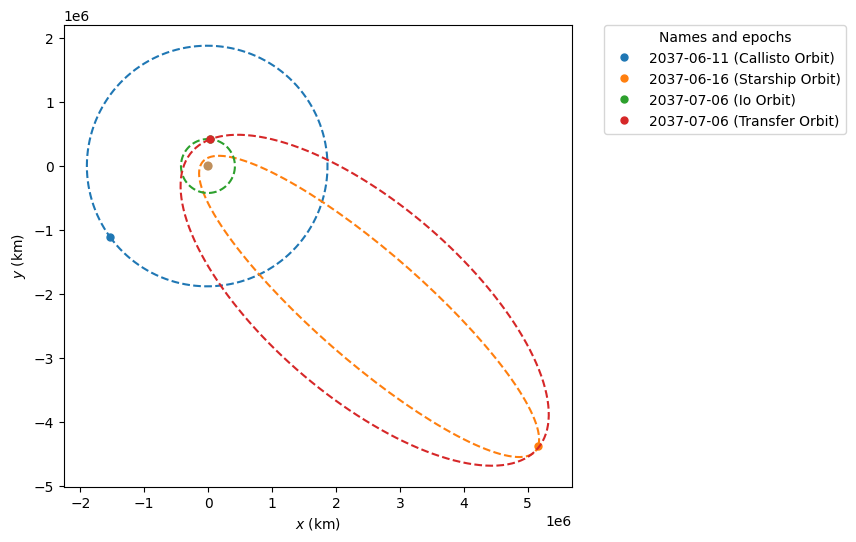

In [20]:
plotter=StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
io_arrival_date_1=transfer_to_io[3]
plotter.plot(callisto_orb, label="Callisto Orbit")
plotter.plot(starship_orb.propagate(5*u.day), label="Starship Orbit")
plotter.plot(io_orb.propagate(io_arrival_date_1), label="Io Orbit")
plotter.plot(transfer_to_io[1].propagate(io_arrival_date_1), label="Transfer Orbit")
print(f"Arrival on Io at {transfer_to_io[3]}")
pre_io_starship_flyby=transfer_to_io[1].propagate(io_arrival_date_1)

In [21]:
test_orb=resonance_search(pre_io_starship_flyby,Io,lower=True, max_numerator=20)

Going for [14  1] resonance with periapsis at 282.2317231723172 km, time till next encounter is 24.79 d
Flyby v inf speed is 11.20 km / s
Spacecraft does 0 complete orbits before arriving, Io (☽) does 13.
Arrives with distance of 169.05 km


In [ ]:
orbits_post_io=multiple_resonances(pre_io_starship_flyby,Io,10,lower=True,max_num=17)

Flyby 1
Going for [14  1] resonance with periapsis at 282.2317231723172 km, time till next encounter is 24.79 d
Flyby v inf speed is 11.20 km / s
Spacecraft does 0 complete orbits before arriving, Io (☽) does 13.
Arrives with distance of 169.05 km
Flyby 2


17.109681877502645
3.6576520553907588
2037-11-01 18:56:20.047


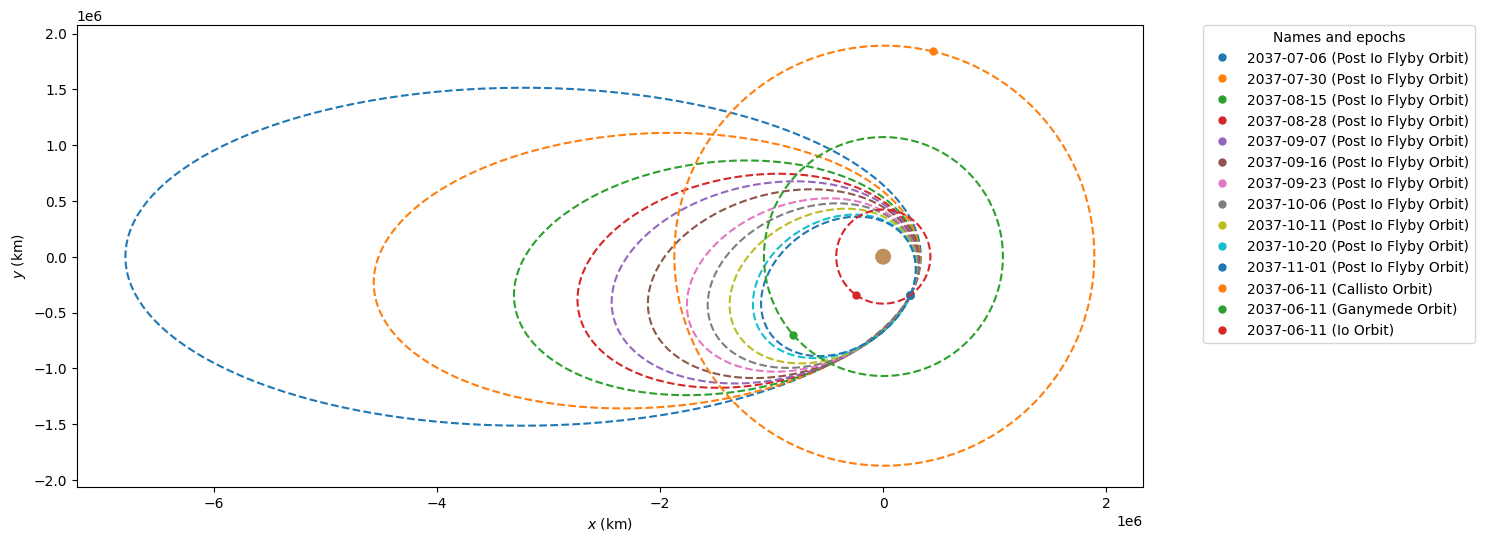

In [ ]:
plotter=StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
for orb in orbits_post_io:
    plotter.plot(orb, label="Post Io Flyby Orbit")
plotter.plot(callisto_orb, label="Callisto Orbit")
plotter.plot(ganymede_orb, label="Ganymede Orbit")
plotter.plot(io_orb, label="Io Orbit")
print((orbits_post_io[-1].r_a/Jupiter.R).to(u.one))
print((orbits_post_io[-1].r_p/Jupiter.R).to(u.one))

search_for_ganymede_1_date=orbits_post_io[-1].epoch
starship_post_io=orbits_post_io[-1]
print(search_for_ganymede_1_date)

In [ ]:
test_assist=slingshot_to_another_body(starship_post_io,Io, Ganymede,date_range=epochs)

NameError: name 'starship_post_io' is not defined

In [ ]:
#Burn to encounter Ganymede
transfer_to_io=get_single_burn_elliptical_hohmann_brute_force(
    ganymede_orb.propagate(search_for_ganymede_1_date),
    starship_post_io,
    max_depature_wait=5*u.day,
    tof_step=0.1*u.day,
    min_tof=1*u.day,
    max_tof=15*u.day,
    retrograde_only=False,
    max_encounter_v=6*u.km/u.s,
    fine_scan=False
)


Best dv: 241.40692355772356 m / s
Refining search around burn at 4.4 d with 8.8 d transfer time.
Best dv: 237.0069293827153 m / s


In [ ]:
print(transfer_to_io[-1])

4.439999999999989 d


Arrival velocity at Ganymede is 4.88 km / s


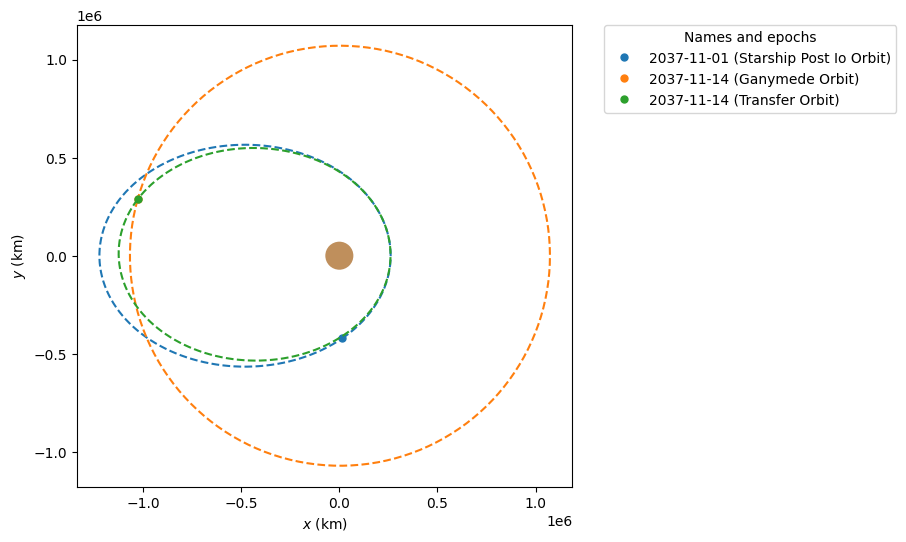

In [ ]:
plotter = StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
plotter.plot(starship_post_io, label="Starship Post Io Orbit")
plotter.plot(ganymede_orb.propagate(transfer_to_io[3]), label="Ganymede Orbit")
plotter.plot(transfer_to_io[1].propagate(transfer_to_io[3]), label="Transfer Orbit")
print(f"Arrival velocity at Ganymede is {np.linalg.norm(transfer_to_io[1].propagate(transfer_to_io[3]).v - ganymede_orb.propagate(transfer_to_io[3]).v):.2f}")
ganymede_arrival_1_date=transfer_to_io[3]
ganymede_starship_flyby_1=transfer_to_io[1].propagate(transfer_to_io[3])

In [ ]:
orbits_post_ganymede=multiple_resonances(ganymede_starship_flyby_1,Ganymede,4,lower=False)

Flyby 1
Going for [3 5] resonance with periapsis at 457.6477647764778 km, time till next encounter is 21.47 d
Flyby v inf speed is 4.88 km / s
Spacecraft does 4 complete orbits before arriving, Ganymede (●) does 2.
Arrives with distance of 126.12 km
Flyby 2
Going for [2 3] resonance with periapsis at 3065.1835183518356 km, time till next encounter is 14.31 d
Flyby v inf speed is 4.88 km / s
Spacecraft does 2 complete orbits before arriving, Ganymede (●) does 1.
Arrives with distance of 132.45 km
Flyby 3
Going for [3 4] resonance with periapsis at 3409.028902890289 km, time till next encounter is 21.47 d
Flyby v inf speed is 4.88 km / s
Spacecraft does 3 complete orbits before arriving, Ganymede (●) does 2.
Arrives with distance of 102.96 km
Flyby 4
Going for [1 1] resonance with periapsis at 264.76497649764997 km, time till next encounter is 7.16 d
Flyby v inf speed is 4.88 km / s
Spacecraft does 0 complete orbits before arriving, Ganymede (●) does 0.
Arrives with distance of 125.40 km

Final orbit has apojove at 21.49 Rj and perijove at 8.46 Rj


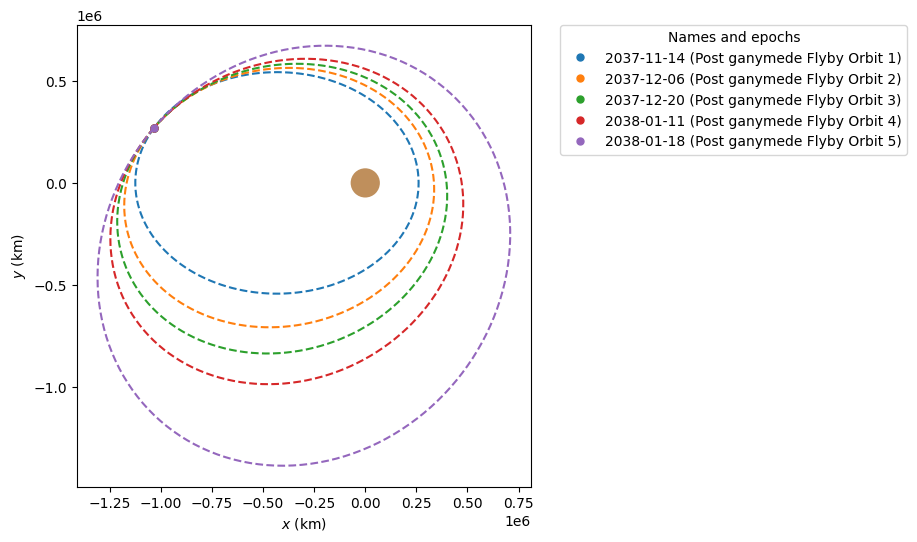

In [ ]:
plotter = StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)  
# plotter.plot(pre_io_starship_flyby, label="Pre Io Flyby Orbit")
for i, orb in enumerate(orbits_post_ganymede):
    plotter.plot(orb, label=f"Post ganymede Flyby Orbit {i+1}")
print(f"Final orbit has apojove at {(orbits_post_ganymede[-1].r_a/Jupiter.R).to(u.one):.2f} Rj and perijove at {(orbits_post_ganymede[-1].r_p/Jupiter.R).to(u.one):.2f} Rj" )